# 04 — Retention Decisioning

This notebook turns the calibrated CatBoost risk scores from notebook 03 into a **targeting decision**. Two framings are covered:

1. **Campaign economics** — given explicit, labeled assumptions about contact cost, customer value, and retention success rate, what threshold maximizes expected net campaign value? How does that recommendation move as the assumptions move?
2. **Budget-constrained targeting** — if the retention team can only contact N% of customers, whom should it contact, and how much better is that than contacting people at random?

**What this is not:** the dataset has no randomized retention treatment, so there is no observed "success rate" or "uplift" to estimate. Every dollar figure below is a **scenario assumption**, not a measured effect. The threshold is chosen by maximizing *expected* net value under those stated assumptions on **validation data** — never by maximizing F1, and never using test for the decision itself. Test is used only to report how the chosen policy performs on held-out data.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from src import data, evaluation, economics
from src.features import select_X_y

%matplotlib inline
pd.set_option("display.max_columns", 30)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
TABLE_DIR = PROJECT_ROOT / "reports" / "tables"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
MODEL_DIR = PROJECT_ROOT / "models"

val = pd.read_csv(PROCESSED_DIR / "val.csv")
test = pd.read_csv(PROCESSED_DIR / "test.csv")
with open(MODEL_DIR / "feature_columns.txt") as f:
    feature_cols = f.read().splitlines()

cat_final = joblib.load(MODEL_DIR / "catboost_final.pkl")

X_val, y_val = select_X_y(val, feature_cols, data.TARGET)
X_test, y_test = select_X_y(test, feature_cols, data.TARGET)

val_proba = cat_final.predict_proba(X_val[feature_cols])[:, 1]
test_proba = cat_final.predict_proba(X_test[feature_cols])[:, 1]

## 1. Campaign economics assumptions (base scenario)

These are illustrative, explicitly-labeled placeholder assumptions, not figures observed in the data:

- **Cost per contact**: \$25 (an outreach call/email + a modest incentive offer).
- **Value of a retained customer**: \$600 (an approximation of a few months of preserved revenue/margin — a real deployment would replace this with an actual CLV/margin figure).
- **Assumed retention success rate**: 30% of true churners who are contacted actually stay, conditional on being reached — an assumption, not an estimate, since we have no randomized outcome data to measure it from.

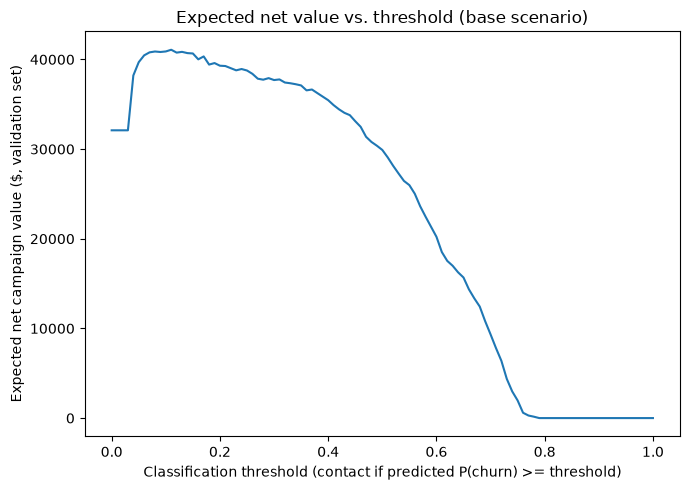

In [2]:
BASE_COST = 25.0
BASE_VALUE = 600.0
BASE_SUCCESS_RATE = 0.30

thresholds = np.round(np.linspace(0.0, 1.0, 101), 3)
val_sweep = economics.threshold_sweep(y_val, val_proba, thresholds, BASE_COST, BASE_VALUE, BASE_SUCCESS_RATE)
val_sweep.to_csv(TABLE_DIR / "economics_threshold_sweep_validation.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(val_sweep["threshold"], val_sweep["net_value"])
ax.set_xlabel("Classification threshold (contact if predicted P(churn) >= threshold)")
ax.set_ylabel("Expected net campaign value ($, validation set)")
ax.set_title("Expected net value vs. threshold (base scenario)")
fig.tight_layout()
fig.savefig(FIG_DIR / "economics_net_value_vs_threshold.png", dpi=150)
plt.show()

In [3]:
best_unconstrained = economics.best_threshold_by_net_value(
    y_val, val_proba, thresholds, BASE_COST, BASE_VALUE, BASE_SUCCESS_RATE
)
print("Unconstrained economic optimum (validation):")
for k, v in best_unconstrained.items():
    print(f"  {k}: {v}")

Unconstrained economic optimum (validation):
  threshold: 0.11
  n_contacted: 812.0
  true_churners_reached: 341.0
  expected_retained: 102.3
  cost: 20300.0
  expected_value_preserved: 61380.0
  net_value: 41080.0
  roi: 2.023645320197044


**Contrast with max-F1 thresholding.** For reference only — this is explicitly *not* how we choose the business threshold — the validation threshold that maximizes F1 is shown below. It optimizes a statistical trade-off that has no connection to dollars, and lands in a different place than the economics-driven optimum above.

In [4]:
from sklearn.metrics import f1_score

f1_scores = [f1_score(y_val, (val_proba >= t).astype(int), zero_division=0) for t in thresholds]
max_f1_threshold = thresholds[int(np.argmax(f1_scores))]
print(f"Max-F1 threshold (validation): {max_f1_threshold:.3f} (F1={max(f1_scores):.3f}) -- NOT used as the business decision.")
print(f"Economic-optimum threshold (validation): {best_unconstrained['threshold']:.3f} -- chosen instead, because it maximizes expected dollars under the stated assumptions.")

Max-F1 threshold (validation): 0.400 (F1=0.641) -- NOT used as the business decision.
Economic-optimum threshold (validation): 0.110 -- chosen instead, because it maximizes expected dollars under the stated assumptions.


Under the base scenario, the economically-optimal policy is far more aggressive than a max-F1 threshold would suggest — it contacts roughly 58% of customers (threshold 0.11) rather than the narrower, higher-precision slice a max-F1 threshold of 0.40 would imply, because contact cost is cheap relative to the value of a retained customer. **This is a direct consequence of the base-scenario assumptions**, not a property of the model — the sensitivity analysis below shows how quickly this recommendation changes when those assumptions change.

## 2. Applying the validation-chosen policy to test (final reporting)

In [5]:
chosen_threshold = best_unconstrained["threshold"]
test_economics = economics.expected_value_at_threshold(
    y_test, test_proba, chosen_threshold, BASE_COST, BASE_VALUE, BASE_SUCCESS_RATE
)
pd.Series(test_economics).to_csv(TABLE_DIR / "economics_test_at_chosen_threshold.csv")
test_economics

{'threshold': 0.11,
 'n_contacted': 795,
 'true_churners_reached': 341,
 'expected_retained': 102.3,
 'cost': 19875.0,
 'expected_value_preserved': 61380.0,
 'net_value': 41505.0,
 'roi': 2.0883018867924528}

## 3. Sensitivity analysis: how the recommended policy moves with the assumptions

In [6]:
sensitivity = economics.sensitivity_grid(
    y_val, val_proba, thresholds,
    cost_values=[10, 25, 50, 100],
    success_rate_values=[0.15, 0.30, 0.50],
    value_values=[300, 600, 1000],
)
sensitivity.to_csv(TABLE_DIR / "economics_sensitivity_grid.csv", index=False)
sensitivity.sort_values(["cost_per_contact", "success_rate", "value_per_retained"])

,cost_per_contact,success_rate,value_per_retained,best_threshold,n_contacted,pct_contacted,net_value,roi
0,10,0.15,300,0.25,595.0,42.228531,7460.0,1.253782
1,10,0.15,600,0.07,946.0,67.139815,22760.0,2.405920
2,10,0.15,1000,0.06,981.0,69.623847,44340.0,4.519878
3,10,0.30,300,0.07,946.0,67.139815,22760.0,2.405920
4,10,0.30,600,0.05,1033.0,73.314407,55190.0,5.342691
5,10,0.30,1000,0.04,1114.0,79.063165,98960.0,8.883303
6,10,0.50,300,0.06,981.0,69.623847,44340.0,4.519878
7,10,0.50,600,0.04,1114.0,79.063165,98960.0,8.883303
8,10,0.50,1000,0.00,1409.0,100.000000,172910.0,12.271824
9,25,0.15,300,0.55,264.0,18.736693,1545.0,0.234091


**Reading the sensitivity grid.** The recommended threshold (and the implied share of customers contacted) swings from "contact essentially everyone" (cost=\$10, success=50%, value=\$1000 -> threshold 0.0, 100% contacted) to "don't run the campaign at all" (cost=\$100 or \$50, success=15%, value=\$300 -> optimal threshold so high that zero customers qualify, net value \$0). There is no single "correct" threshold independent of these business inputs — which is exactly why this is a decision-support tool with stated assumptions, not a model output to be taken at face value. In particular, a pessimistic-but-plausible scenario (expensive contact, low success rate, modest customer value) implies the campaign is not worth running at any threshold — a conclusion the business needs the economics model to see, not something a purely statistical threshold choice would ever surface.

## 4. Budget-constrained targeting: capacity of 20% of the customer base

A more operationally realistic framing for many retention teams: outreach capacity (call-center hours, campaign budget) caps how many customers can be contacted, regardless of what pure economics would prefer. We repeat the sensitivity analysis with a hard cap of 20% of the customer base.

In [7]:
sensitivity_capped = economics.sensitivity_grid(
    y_val, val_proba, thresholds,
    cost_values=[10, 25, 50, 100],
    success_rate_values=[0.15, 0.30, 0.50],
    value_values=[300, 600, 1000],
    max_contact_fraction=0.20,
)
sensitivity_capped.to_csv(TABLE_DIR / "economics_sensitivity_grid_capped20.csv", index=False)
sensitivity_capped.sort_values(["cost_per_contact", "success_rate", "value_per_retained"])

,cost_per_contact,success_rate,value_per_retained,best_threshold,n_contacted,pct_contacted,net_value,roi
0,10,0.15,300,0.54,274.0,19.446416,5585.0,2.038321
1,10,0.15,600,0.54,274.0,19.446416,13910.0,5.076642
2,10,0.15,1000,0.54,274.0,19.446416,25010.0,9.127737
3,10,0.30,300,0.54,274.0,19.446416,13910.0,5.076642
4,10,0.30,600,0.54,274.0,19.446416,30560.0,11.153285
5,10,0.30,1000,0.54,274.0,19.446416,52760.0,19.255474
6,10,0.50,300,0.54,274.0,19.446416,25010.0,9.127737
7,10,0.50,600,0.54,274.0,19.446416,52760.0,19.255474
8,10,0.50,1000,0.54,274.0,19.446416,89760.0,32.759124
9,25,0.15,300,0.55,264.0,18.736693,1545.0,0.234091


With a 20% capacity cap, most profitable scenarios simply target the full 20% allowance (the constraint binds), and the decision question changes from "what threshold" to "is a 20% capacity enough, and which 20% should it be" — which is exactly the Top-K framing in the next section.

## 5. "If we can only contact N% of customers, whom should we contact?" (test set)

In [8]:
policy_comparison = economics.targeting_policy_comparison(y_test, test_proba, k_fractions=(0.05, 0.10, 0.20))
policy_comparison.to_csv(TABLE_DIR / "targeting_policy_comparison_test.csv", index=False)
policy_comparison

,top_k_pct,n_contacted,model_churners_captured,model_recall,random_churners_captured_expected,random_recall,lift_vs_random
0,5.0,70,60,0.160428,18.7,0.05,3.208556
1,10.0,141,111,0.296791,37.4,0.10,2.967914
2,20.0,282,194,0.518717,74.8,0.20,2.593583
3,100.0,1409,374,1.000000,374.0,1.00,1.000000


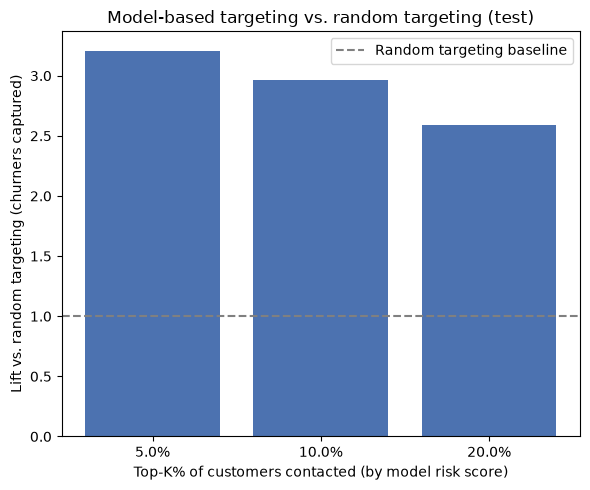

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_df = policy_comparison[policy_comparison["top_k_pct"] < 100]
ax.bar(plot_df["top_k_pct"].astype(str) + "%", plot_df["lift_vs_random"], color="#4C72B0")
ax.axhline(1.0, color="grey", linestyle="--", label="Random targeting baseline")
ax.set_ylabel("Lift vs. random targeting (churners captured)")
ax.set_xlabel("Top-K% of customers contacted (by model risk score)")
ax.set_title("Model-based targeting vs. random targeting (test)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "targeting_lift_vs_random.png", dpi=150)
plt.show()

Model-based targeting captures 2.5x-3.2x as many churners as random targeting of the same size, across every capacity level tested. This is the headline, assumption-free result of the project: **regardless of exactly how the economics are priced, risk-based targeting is a large, robust improvement over random or blanket outreach.**

## 6. Final product recommendation

- **Model to use:** CatBoost, calibrated with sigmoid scaling fit on validation. It matches Logistic Regression on ROC-AUC and clearly exceeds it on PR-AUC and every Top-K ranking metric (notebook 03), which is what matters for a targeting/ranking use case with a minority positive class.
- **Ranking quality:** Top 10% of customers by predicted risk captures ~30% of all churners at ~3x lift over random targeting; this holds up on the held-out test set, not just validation.
- **Calibration:** Sigmoid calibration (fit on validation) reduces the test Brier score meaningfully; probabilities are usable as inputs to the economics model, though they should be re-validated whenever the model is retrained or the customer base shifts materially.
- **Targeting policy:** There is no single "correct" threshold. We recommend the business supply its own cost/value/success-rate assumptions into the sensitivity model above (Section 3) rather than accept a single hardcoded number; where outreach capacity is fixed (Section 4-5), a Top-10% to Top-20% risk-ranked target list is a robust, assumption-light starting point that consistently beats random targeting by ~2.5-3x.
- **Sensitivity:** The economically "optimal" threshold is highly sensitive to contact cost and assumed success rate — cheap, high-conviction campaigns should target broadly; expensive or lower-confidence campaigns should target narrowly. This sensitivity is a feature to communicate to stakeholders, not a weakness to hide.
- **Segments to investigate:** Month-to-month, low-tenure, fiber-optic, electronic-check customers concentrate both churn risk and the campaign's targeted population. The model's blind spot in long-contract segments (0% recall among 1-2 year contract churners at the default reporting threshold) is worth a dedicated look — those churners look different from the typical month-to-month churner and the model may need contract-specific features or a separate treatment path.
- **What cannot be concluded from this dataset:** any causal claim that contacting a customer would actually prevent their churn, or what the true retention success rate would be. This is an observational, single-snapshot dataset with no randomized intervention.
- **What to test next, experimentally:** see the A/B test design below.

## 7. A/B test design for a real retention intervention

This design is proposed for the business to run; **no result is reported or implied here** — the dataset used in this project cannot supply one.

- **Unit of randomization:** individual customer (not household/account-group, to avoid interference between related accounts on the same contract).
- **Eligible population:** customers above a pre-registered risk-score threshold (e.g., the Top 20% by CatBoost score), to concentrate the test where the intervention is most likely to matter and to keep the sample size for the primary metric feasible given the churn base rate.
- **Control:** no proactive retention contact (standard experience).
- **Treatment:** proactive retention contact (e.g., a support/loyalty call plus a contract or bundled-service offer, informed by the actionable levers identified in notebook 03 — contract terms, security/support add-ons, payment method).
- **Primary metric:** 60-day (or one full billing-cycle-appropriate horizon) churn rate, treatment vs. control, tested with a standard two-proportion test; report absolute and relative risk reduction with a confidence interval, not just a p-value.
- **Guardrails:** cost per contact vs. budget; complaint/opt-out rate; short-term revenue impact of any discount offered (avoid a "win" that is actually a margin giveaway to customers who would not have churned anyway); support-team handling capacity.
- **Major validity risks:**
  - **Contamination/spillover** — treated and control customers may discuss offers (e.g., via review sites, word of mouth, shared households), diluting the measured effect.
  - **Novelty/Hawthorne effects** — a one-off proactive contact may change behavior temporarily regardless of the specific offer content.
  - **Selection into the eligible population** — since eligibility is itself risk-score-based, results generalize to "high-risk customers as scored by this model," not to the full customer base; recalibrate the model periodically so this population doesn't drift.
  - **Underpowered subgroups** — notebook 03 shows the model rarely flags long-contract customers, so an A/B test gated on the risk score will have very little power to detect an effect in that segment; a separate, deliberately-oversampled test arm would be needed to learn anything there.
  - **Seasonality** — churn and promotional responsiveness can be seasonal; run the test across a full relevant cycle, not a short window that happens to coincide with unrelated promotions or price changes.